# NYC Taxi EDA -> Interpretable Modeling (v2 — Cleaning)

**Mubeen Yacub my558@drexel.edu**
**Caleb Solomons cs3889@drexel.edu**  
**Mai Lam mnl49@drexel.edu**
**Anh Minh Tran at3654@drexel.edu**


## What we're doing
- Use EDA to make the patterns obvious (time-of-day, locations, payment types).
- Fit an interpretable regression model for `total_amount` (log-linear).
- Fit an interpretable classification model for tipping (`tip_amount > 0`).
- Use feature importance (permutation) to sanity-check what's actually driving predictions.

## v2 Changelog (Enhanced Cleaning & Lookups)
- **Fare amount validation**: filter negative fares, enforce minimum base fare ($2.50).
- **Tip amount capping**: cap at 99.9th percentile to remove data entry errors.
- **Speed-based plausibility filter**: drop trips with impossible distance/duration combos.
- **Passenger count cleanup**: replace 0s with NaN, cap at legal max of 6.
- **RatecodeID validation**: restrict to known codes (1–6, 99).
- **Store-and-forward flag**: explicit NaN → "N" imputation before pipeline.
- **Congestion surcharge / airport fee**: deterministic fill (0) instead of median imputation.
- **Duplicate trip detection**: dedup on pickup/dropoff datetime + locations + fare.
- **Unified lookup dictionaries**: VendorID, RatecodeID, payment_type, and taxi zone lookups all applied to the dataframe with human-readable columns.
- **Cleaning audit log**: row counts printed after every step for full transparency.

## Drive setup 



In [ ]:

from google.colab import drive
drive.mount('/content/drive')


DATA_PATH = "/content/drive/MyDrive/DSCI 591/2023_Yellow_Taxi_Trip_Data_20260112.csv"


READ_NROWS = None  #)

# Taxi zone lookup path (used to convert PULocationID/DOLocationID into zone names)
ZONE_LOOKUP_PATH = "/content/drive/MyDrive/DSCI 591/taxi_zone_lookup.csv"


Mounted at /content/drive


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix, roc_curve
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)

## 1) Load the dataset



In [ ]:
def load_taxi_data(path: str, read_nrows: int | None = None) -> pd.DataFrame:

    """Load taxi data.

    NOTE: The NYC taxi CSV can be very large. If loading feels like it 'hangs',
    set READ_NROWS in the cell above (e.g., 5_000_000) and/or restrict columns.
    """
    if path.lower().endswith(".parquet"):
        return pd.read_parquet(path)

    if path.lower().endswith(".csv"):
        
        #load columns actually used downstream

        usecols = [
            "VendorID","tpep_pickup_datetime","tpep_dropoff_datetime","passenger_count",
            "trip_distance","RatecodeID","store_and_fwd_flag","PULocationID","DOLocationID",
            "payment_type","fare_amount","extra","mta_tax","tip_amount","tolls_amount",
            "improvement_surcharge","total_amount","congestion_surcharge","airport_fee",
        ]

        
        try:
            return pd.read_csv(path, usecols=usecols, nrows=read_nrows)
        
        except ValueError:
            return pd.read_csv(path, nrows=read_nrows)

    raise ValueError("Unsupported file type. Use .parquet or .csv")

df_raw = load_taxi_data(DATA_PATH, read_nrows=READ_NROWS)

print("Raw shape:", df_raw.shape)

df_raw.head()


Raw shape: (38310226, 19)


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,01/01/2023 12:32:10 AM,01/01/2023 12:40:36 AM,1.0,0.97,1.0,N,161,141,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.00
1,2,01/01/2023 12:55:08 AM,01/01/2023 01:01:27 AM,1.0,1.1,1.0,N,43,237,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.00
2,2,01/01/2023 12:25:04 AM,01/01/2023 12:37:49 AM,1.0,2.51,1.0,N,48,238,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.00
3,1,01/01/2023 12:03:48 AM,01/01/2023 12:13:25 AM,0.0,1.9,1.0,N,138,7,1,12.1,7.25,0.5,0.0,0.0,1.0,20.85,0.0,1.25
4,2,01/01/2023 12:10:29 AM,01/01/2023 12:21:19 AM,1.0,1.43,1.0,N,107,79,1,11.4,1.0,0.5,3.28,0.0,1.0,19.68,2.5,0.00


## 2) Quick schema check
Take a peak at columns + dtypes + missingness.


In [ ]:
df_raw.info()

missing = df_raw.isna().mean().sort_values(ascending=False)
missing.head(25)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38310226 entries, 0 to 38310225
Data columns (total 19 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               int64  
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          object 
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           int64  
 10  fare_amount            object 
 11  extra                  object 
 12  mta_tax                float64
 13  tip_amount             object 
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           object 
 17  congestion_surcharge   float64
 18  airport_fee            float64
dtypes: float64(7), int64(4), object(8)
memory usage: 5.4+ GB


,0
store_and_fwd_flag,0.034178
RatecodeID,0.034178
passenger_count,0.034178
airport_fee,0.034178
congestion_surcharge,0.034178
VendorID,0.000000
tpep_pickup_datetime,0.000000
tpep_dropoff_datetime,0.000000
DOLocationID,0.000000
PULocationID,0.000000


## 3) Clean + engineer features 

Full cleaning pipeline with audit trail. Every filter prints a before/after row count so nothing is opaque.

**New in v2:**
- Fare amount floor ($2.50 base fare) and non-negative enforcement
- Tip amount capped at 99.9th percentile
- Speed-based plausibility filter (0.5–80 mph)
- Passenger count: 0 → NaN, cap at 6
- RatecodeID restricted to valid codes
- Congestion surcharge and airport fee: NaN → 0 (deterministic)
- Store-and-forward flag: NaN → "N"
- Deduplication on key trip identifiers

In [ ]:
df = df_raw.copy()
audit_log = []  # track row counts after each step

def audit(step_name, dataframe):

    """Record row count after a cleaning step for the audit trail."""

    audit_log.append({"step": step_name, "rows": len(dataframe)})

    print(f"  [{step_name}] → {len(dataframe):,} rows")

    return dataframe

print("=== CLEANING PIPELINE ===\n")
audit("raw_input", df)

# numeric columns
to_num = [
    "trip_distance", "fare_amount", "extra", "tip_amount",
    "tolls_amount", "total_amount", "congestion_surcharge", "airport_fee",
    "passenger_count", "RatecodeID"
]

for c in to_num:

    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")


# drop missing row values 

df = df.dropna(subset=["trip_distance", "total_amount", "tip_amount", "fare_amount"])
df = audit("drop_missing_critical", df)


# fare validation, non-negative + minimum base fare

df = df[(df["fare_amount"] >= 2.50)]
df = audit("fare_floor_2.50", df)


# distance and total_amount range filters

df = df[(df["trip_distance"] > 0) & (df["trip_distance"] < 100)]
df = df[(df["total_amount"] > 0) & (df["total_amount"] < 500)]
df = audit("distance_and_total_range", df)


# tip amount cap

tip_cap = df["tip_amount"].quantile(0.999)
print(f"  tip_amount cap (99.9th pct): ${tip_cap:.2f}")
df["tip_amount"] = df["tip_amount"].clip(upper=tip_cap)


# Passenger count, 0 -> NaN, cap at 6

if "passenger_count" in df.columns:
    df["passenger_count"] = df["passenger_count"].replace(0, np.nan)

    df.loc[df["passenger_count"] > 6, "passenger_count"] = np.nan

    audit("passenger_count_cleanup", df)


# RatecodeID: restrict to valid codes

valid_ratecodes = {1, 2, 3, 4, 5, 6, 99}

if "RatecodeID" in df.columns:
    df.loc[~df["RatecodeID"].isin(valid_ratecodes), "RatecodeID"] = np.nan

    audit("ratecode_validation", df)


# congestion surcharge + airport fee: NaN -> 0

for col in ["congestion_surcharge", "airport_fee"]:

    if col in df.columns:
        df[col] = df[col].fillna(0)


# store + forward flag: NaN -> "N" 

if "store_and_fwd_flag" in df.columns:
    df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna("N")


# deduplication key trip identifiers

pickup_col = "tpep_pickup_datetime" if "tpep_pickup_datetime" in df.columns else None
dropoff_col = "tpep_dropoff_datetime" if "tpep_dropoff_datetime" in df.columns else None

if pickup_col is None or dropoff_col is None:
    raise ValueError("Could not find pickup/dropoff datetime columns.")

dedup_cols = [pickup_col, dropoff_col, "PULocationID", "DOLocationID", "fare_amount"]
dedup_cols = [c for c in dedup_cols if c in df.columns]

before_dedup = len(df)

df = df.drop_duplicates(subset=dedup_cols, keep="first")

print(f"  [dedup] removed {before_dedup - len(df):,} duplicate rows")
df = audit("dedup", df)

# Early sample for speed 

#EARLY_SAMPLE_N = 500_000

#if len(df) > EARLY_SAMPLE_N:
#    df = df.sample(EARLY_SAMPLE_N, random_state=42).reset_index(drop=True)

#    audit("early_sample", df)


# parse datetimes

df[pickup_col] = pd.to_datetime(df[pickup_col], errors="coerce")

df = df[df[pickup_col].dt.year == 2023]
df = audit("year_filter_2023", df)

#if len(df) > EARLY_SAMPLE_N:
    #df = df.sample(EARLY_SAMPLE_N, random_state=42).reset_index(drop=True)

df[dropoff_col] = pd.to_datetime(df[dropoff_col], errors="coerce")

df = df.dropna(subset=[pickup_col, dropoff_col])
df = audit("drop_bad_datetimes", df)


# trip duration

df["trip_duration_min"] = (df[dropoff_col] - df[pickup_col]).dt.total_seconds() / 60

df = df[(df["trip_duration_min"] > 1) & (df["trip_duration_min"] < 300)]
df = audit("duration_filter", df)


# speed plausibility filter

df["speed_mph"] = df["trip_distance"] / (df["trip_duration_min"] / 60)

df = df[(df["speed_mph"] > 0.5) & (df["speed_mph"] < 80)]
df = audit("speed_filter", df)


# temporal features

df["pickup_hour"] = df[pickup_col].dt.hour
df["pickup_dow"] = df[pickup_col].dt.dayofweek
df["is_weekend"] = (df["pickup_dow"] >= 5).astype(int)
df["is_night"] = df["pickup_hour"].isin([20, 21, 22, 23, 0, 1, 2, 3, 4, 5]).astype(int)


# tip target

df["tipped"] = (df["tip_amount"] > 0).astype(int)

print(f"\n=== FINAL CLEANED SHAPE: {df.shape} ===")

df[["trip_distance", "trip_duration_min", "speed_mph", "pickup_hour",
    "pickup_dow", "total_amount", "tip_amount", "tipped"]].head()

=== CLEANING PIPELINE ===

  [raw_input] → 38,310,226 rows
  [drop_missing_critical] → 38,309,278 rows
  [fare_floor_2.50] → 37,906,043 rows
  [distance_and_total_range] → 37,181,122 rows
  tip_amount cap (99.9th pct): $29.13
  [passenger_count_cleanup] → 37,181,122 rows
  [ratecode_validation] → 37,181,122 rows
  [dedup] removed 26 duplicate rows
  [dedup] → 37,181,096 rows
  [year_filter_2023] → 37,181,004 rows
  [drop_bad_datetimes] → 37,181,004 rows
  [duration_filter] → 37,031,130 rows
  [speed_filter] → 37,017,621 rows

=== FINAL CLEANED SHAPE: (37017621, 26) ===


,trip_distance,trip_duration_min,speed_mph,pickup_hour,pickup_dow,total_amount,tip_amount,tipped
0,0.97,8.433333,6.901186,0,6,14.30,0.00,0
1,1.10,6.316667,10.448549,0,6,16.90,4.00,1
2,2.51,12.750000,11.811765,0,6,34.90,15.00,1
3,1.90,9.616667,11.854419,0,6,20.85,0.00,0
4,1.43,10.833333,7.920000,0,6,19.68,3.28,1


## 3a) Cleaning audit summary
Visual summary of how many rows each cleaning step removed.

                    step     rows  rows_removed
               raw_input 38310226             0
   drop_missing_critical 38309278           948
         fare_floor_2.50 37906043        403235
distance_and_total_range 37181122        724921
 passenger_count_cleanup 37181122             0
     ratecode_validation 37181122             0
                   dedup 37181096            26
        year_filter_2023 37181004            92
      drop_bad_datetimes 37181004             0
         duration_filter 37031130        149874
            speed_filter 37017621         13509


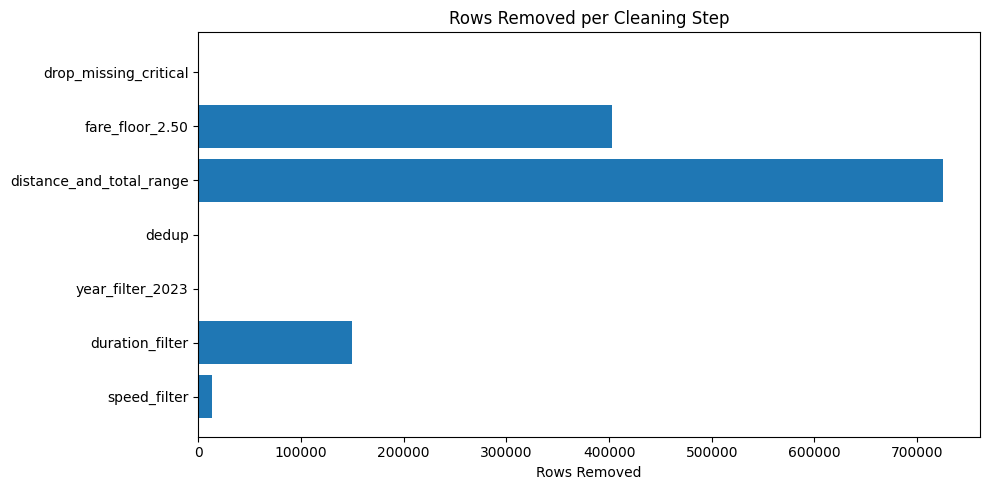

In [ ]:
audit_df = pd.DataFrame(audit_log)
audit_df["rows_removed"] = -audit_df["rows"].diff().fillna(0).astype(int)
audit_df.loc[0, "rows_removed"] = 0  # first row is the starting count

print(audit_df.to_string(index=False))


# rows removed per step (excluding raw_input)

plot_df = audit_df[audit_df["rows_removed"] > 0].copy()

if len(plot_df) > 0:
    plt.figure(figsize=(10, 5))
    plt.barh(plot_df["step"], plot_df["rows_removed"])
    plt.xlabel("Rows Removed")
    plt.title("Rows Removed per Cleaning Step")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## 3b) Lookup dictionaries -> human-readable columns

Map all coded fields to their human-readable labels:
- **VendorID** -> vendor name
- **RatecodeID** -> rate code description  
- **payment_type** ->→ payment method name
- **PULocationID / DOLocationID** -> taxi zone name + borough (from TLC lookup CSV)

These readable columns are used in EDA (plots, tables) while the original numeric codes stay available for modeling.

In [ ]:
vendor_map = {
    1: "Creative Mobile Technologies",
    2: "Curb Mobility",
    6: "Myle Technologies",
    7: "Helix"
}

ratecode_map = {
    1: "Standard",
    2: "JFK",
    3: "Newark",
    4: "Nassau/Westchester",
    5: "Negotiated",
    6: "Group ride",
    99: "Unknown"
}

payment_map = {
    0: "Unknown",
    1: "Credit card",
    2: "Cash",
    3: "No charge",
    4: "Dispute"
}


df["vendor_name"] = df["VendorID"].map(vendor_map)
df["ratecode_name"] = df["RatecodeID"].map(ratecode_map)
df["payment_name"] = df["payment_type"].map(payment_map)


taxizone_lookup = pd.read_csv(ZONE_LOOKUP_PATH)
taxizone_lookup = taxizone_lookup[["LocationID", "Borough", "Zone", "service_zone"]]

id_to_zone = dict(zip(taxizone_lookup["LocationID"], taxizone_lookup["Zone"]))
id_to_borough = dict(zip(taxizone_lookup["LocationID"], taxizone_lookup["Borough"]))
id_to_service = dict(zip(taxizone_lookup["LocationID"], taxizone_lookup["service_zone"]))

df["PU_zone"] = df["PULocationID"].map(id_to_zone)
df["PU_borough"] = df["PULocationID"].map(id_to_borough)
df["PU_service_zone"] = df["PULocationID"].map(id_to_service)
df["DO_zone"] = df["DOLocationID"].map(id_to_zone)
df["DO_borough"] = df["DOLocationID"].map(id_to_borough)
df["DO_service_zone"] = df["DOLocationID"].map(id_to_service)


print("=== Lookup Coverage ===")

for col, name in [("vendor_name", "VendorID"), ("ratecode_name", "RatecodeID"),
                   ("payment_name", "payment_type"), ("PU_zone", "PULocationID"),
                   ("DO_zone", "DOLocationID")]:
    
    mapped = df[col].notna().sum()
    total = len(df)

    print(f"  {name} → {col}: {mapped:,}/{total:,} mapped ({mapped/total*100:.1f}%)")

print("\nZone lookup table shape:", taxizone_lookup.shape)
print("\nSample mapped rows:")

df[["VendorID", "vendor_name", "RatecodeID", "ratecode_name",
    "payment_type", "payment_name", "PULocationID", "PU_borough",
    "PU_zone", "DOLocationID", "DO_borough", "DO_zone"]].head(10)

=== Lookup Coverage ===
  VendorID → vendor_name: 37,017,621/37,017,621 mapped (100.0%)
  RatecodeID → ratecode_name: 36,018,299/37,017,621 mapped (97.3%)
  payment_type → payment_name: 37,017,621/37,017,621 mapped (100.0%)
  PULocationID → PU_zone: 36,701,559/37,017,621 mapped (99.1%)
  DOLocationID → DO_zone: 36,691,169/37,017,621 mapped (99.1%)

Zone lookup table shape: (265, 4)

Sample mapped rows:


,VendorID,vendor_name,RatecodeID,ratecode_name,payment_type,payment_name,PULocationID,PU_borough,PU_zone,DOLocationID,DO_borough,DO_zone
0,2,Curb Mobility,1.0,Standard,2,Cash,161,Manhattan,Midtown Center,141,Manhattan,Lenox Hill West
1,2,Curb Mobility,1.0,Standard,1,Credit card,43,Manhattan,Central Park,237,Manhattan,Upper East Side South
2,2,Curb Mobility,1.0,Standard,1,Credit card,48,Manhattan,Clinton East,238,Manhattan,Upper West Side North
3,1,Creative Mobile Technologies,1.0,Standard,1,Credit card,138,Queens,LaGuardia Airport,7,Queens,Astoria
4,2,Curb Mobility,1.0,Standard,1,Credit card,107,Manhattan,Gramercy,79,Manhattan,East Village
5,2,Curb Mobility,1.0,Standard,1,Credit card,161,Manhattan,Midtown Center,137,Manhattan,Kips Bay
6,2,Curb Mobility,1.0,Standard,1,Credit card,239,Manhattan,Upper West Side South,143,Manhattan,Lincoln Square West
7,2,Curb Mobility,1.0,Standard,1,Credit card,142,Manhattan,Lincoln Square East,200,Bronx,Riverdale/North Riverdale/Fieldston
8,2,Curb Mobility,1.0,Standard,1,Credit card,164,Manhattan,Midtown South,236,Manhattan,Upper East Side North
9,2,Curb Mobility,1.0,Standard,2,Cash,141,Manhattan,Lenox Hill West,107,Manhattan,Gramercy


In [ ]:
CLEAN_OUTPUT_PATH = "/content/drive/MyDrive/DSCI 591/2023_Yellow_Taxi_Cleaned.parquet"

df.to_parquet(CLEAN_OUTPUT_PATH, index=False)

print(f"Saved cleaned dataset: {df.shape[0]:,} rows × {df.shape[1]} cols")
print(f"→ {CLEAN_OUTPUT_PATH}")

# download directly local machine
from google.colab import files
files.download(CLEAN_OUTPUT_PATH)

Saved cleaned dataset: 37,017,621 rows × 35 cols
→ /content/drive/MyDrive/DSCI 591/2023_Yellow_Taxi_Cleaned.parquet


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 4) Sampling for speed
A random sample still captures the core structure while keeping runtime reasonable.


In [ ]:
SAMPLE_N = None  # set to None to use full cleaned dataset, default was 300,000

if SAMPLE_N is not None and len(df) > SAMPLE_N:
    df = df.sample(n=SAMPLE_N, random_state=42).reset_index(drop=True)
    
print("Working shape:", df.shape)


Working shape: (37017621, 35)


## 5) EDA — baseline distributions
Distributions that drive everything: distance, duration, total, tip.
This also motivates using `log1p(total_amount)` later (right-skew).


In [ ]:
eda_cols = ["trip_distance", "trip_duration_min", "total_amount", "tip_amount"]
df[eda_cols].describe(percentiles=[.5, .9, .95, .99])


,trip_distance,trip_duration_min,total_amount,tip_amount
count,3.701762e+07,3.701762e+07,3.701762e+07,3.701762e+07
mean,3.532126e+00,1.652938e+01,2.889410e+01,3.577783e+00
std,4.551748e+00,1.324383e+01,2.243043e+01,3.845814e+00
min,1.000000e-02,1.016667e+00,3.030000e+00,-5.780000e+00
50%,1.820000e+00,1.278333e+01,2.100000e+01,2.880000e+00
90%,9.300000e+00,3.256667e+01,6.005000e+01,7.610000e+00
95%,1.569000e+01,4.298333e+01,8.265000e+01,1.200000e+01
99%,2.030000e+01,6.653333e+01,1.037000e+02,1.754000e+01
max,9.992000e+01,2.999833e+02,4.999500e+02,2.913000e+01


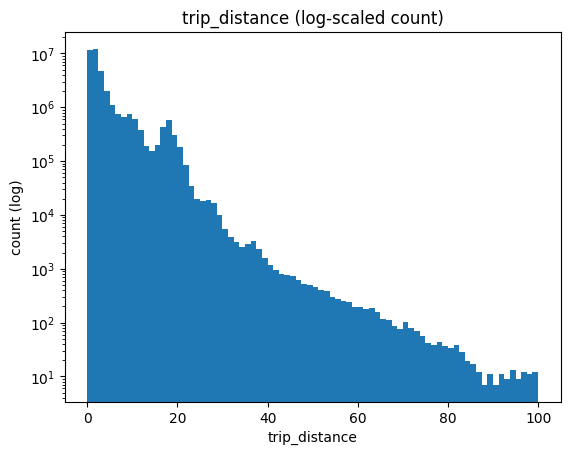

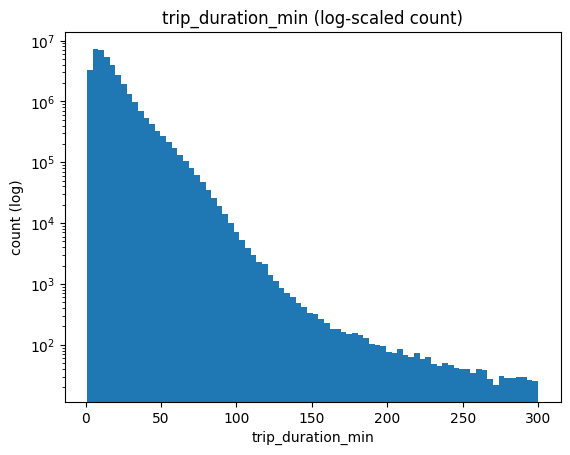

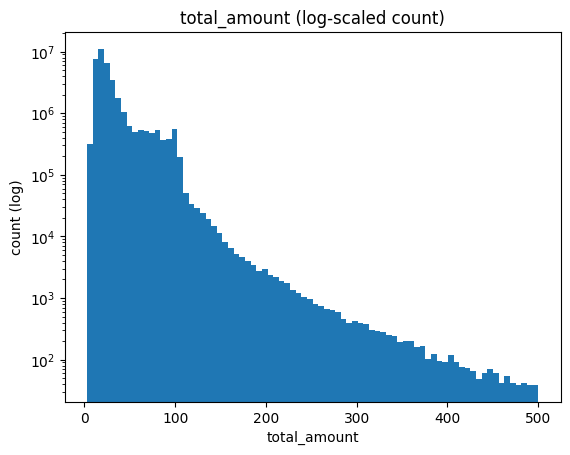

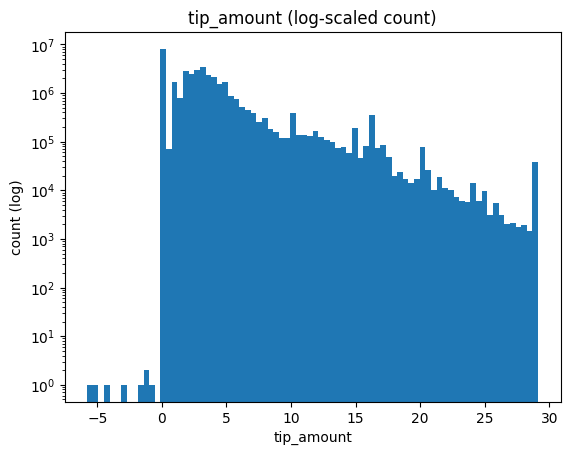

In [ ]:
# plot each column instead of repeating trip_distance

for col in eda_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=80)
    plt.yscale("log")
    plt.title(f"{col} (log-scaled count)")
    plt.xlabel(col)  #revert to just col if issues occur
    plt.ylabel("count (log)")
    plt.show()


## 6) EDA — time of day (fare + tip behavior)

Check whether fares and tips shift by time of day with mean/median total, mean tip, and tip rate.


In [ ]:
hourly = df.groupby("pickup_hour").agg(
    trips=("pickup_hour", "size"),
    mean_total=("total_amount", "mean"),
    median_total=("total_amount", "median"),
    mean_tip=("tip_amount", "mean"),
    tip_rate=("tipped", "mean")
).reset_index()

hourly.head()


,pickup_hour,trips,mean_total,median_total,mean_tip,tip_rate
0,0,1037945,29.270554,22.00,3.571337,0.789436
1,1,693633,26.759225,20.80,3.233938,0.786347
2,2,456112,25.324240,20.52,3.000220,0.772220
3,3,298552,26.659926,20.52,3.083025,0.747123
4,4,198071,34.197433,23.60,3.800491,0.681892


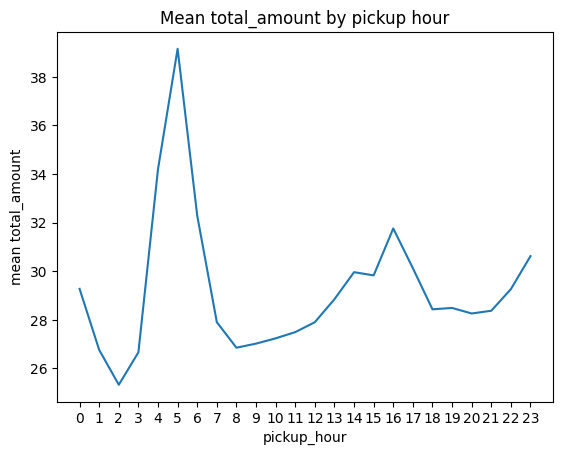

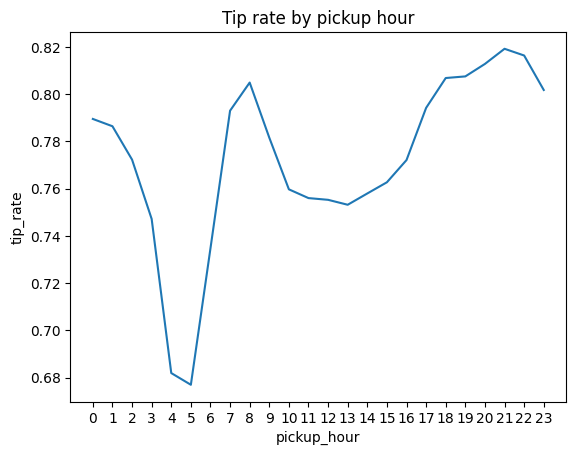

In [ ]:
plt.figure()
plt.plot(hourly["pickup_hour"], hourly["mean_total"])
plt.title("Mean total_amount by pickup hour")
plt.xlabel("pickup_hour")
plt.ylabel("mean total_amount")
plt.xticks(range(0,24))
plt.show()

plt.figure()
plt.plot(hourly["pickup_hour"], hourly["tip_rate"])
plt.title("Tip rate by pickup hour")
plt.xlabel("pickup_hour")
plt.ylabel("tip_rate")
plt.xticks(range(0,24))
plt.show()


## 7) EDA — pickup/dropoff hotspots
Top-15 pickup and dropoff zones by trip count.


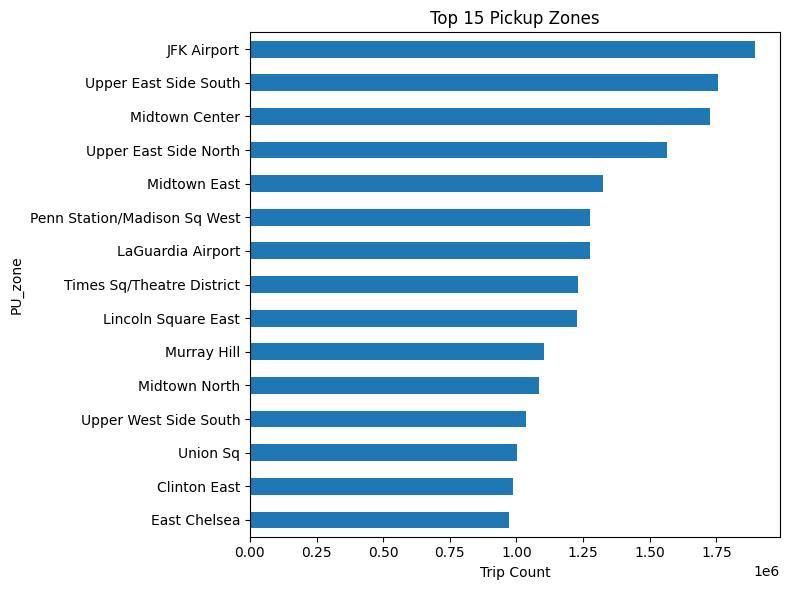

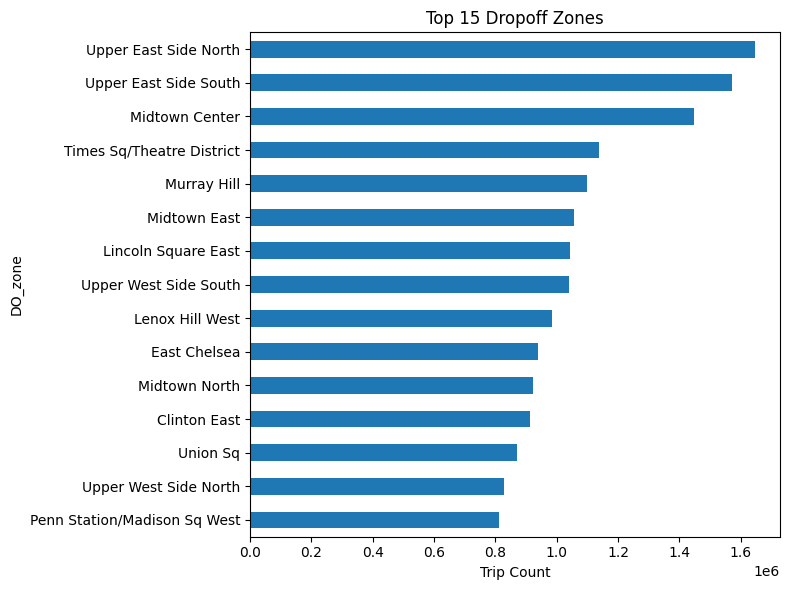

In [ ]:
# Prefer human-readable zone labels if available; otherwise fall back to numeric IDs.

pu_label_col = "PU_zone" if "PU_zone" in df.columns else "PULocationID"
do_label_col = "DO_zone" if "DO_zone" in df.columns else "DOLocationID"

top_pu = df[pu_label_col].value_counts().head(15)
top_do = df[do_label_col].value_counts().head(15)

plt.figure(figsize=(8,6))

top_pu.sort_values().plot(kind="barh")

plt.title("Top 15 Pickup Locations" if pu_label_col=="PULocationID" else "Top 15 Pickup Zones")
plt.xlabel("Trip Count")
plt.ylabel(pu_label_col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))

top_do.sort_values().plot(kind="barh")

plt.title("Top 15 Dropoff Locations" if do_label_col=="DOLocationID" else "Top 15 Dropoff Zones")
plt.xlabel("Trip Count")
plt.ylabel(do_label_col)
plt.tight_layout()
plt.show()


## 8) EDA — payment type vs total + tips

Checking whether payment type related to cost and tipping.


In [ ]:
if "payment_type" not in df.columns:
    raise ValueError("payment_type column not found.")


pay_col = "payment_name" if "payment_name" in df.columns else "payment_type"

pay_summary = df.groupby(pay_col).agg(
    trips=(pay_col, "size"),
    mean_total=("total_amount", "mean"),
    median_total=("total_amount", "median"),
    tip_rate=("tipped", "mean"),
    mean_tip=("tip_amount", "mean")
).reset_index().sort_values("trips", ascending=False)

pay_summary

,payment_name,trips,mean_total,median_total,tip_rate,mean_tip
1,Credit card,29525455,29.630880,21.80,0.955678,4.365783
0,Cash,6141349,25.157501,17.80,0.000065,0.000313
4,Unknown,999322,31.320795,25.64,0.771526,3.535679
2,Dispute,229350,26.160753,17.50,0.001509,0.014374
3,No charge,122145,23.946463,16.10,0.000982,0.006292


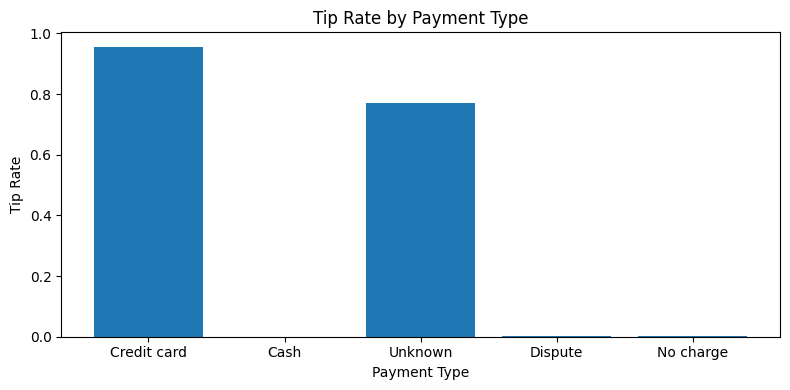

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(pay_summary[pay_col].astype(str), pay_summary["tip_rate"])
plt.title("Tip Rate by Payment Type")
plt.xlabel("Payment Type")
plt.ylabel("Tip Rate")
plt.tight_layout()
plt.show()

## 9) Modeling setup
Everything goes through a `ColumnTransformer` pipeline:
- numeric: median impute + standardize
- categorical: most-frequent impute + one-hot encode

This keeps preprocessing honest and reproducible.


In [ ]:
def make_preprocess(X: pd.DataFrame) -> ColumnTransformer:
    
    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    numeric_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, num_cols),
            ("cat", categorical_pipe, cat_cols),
        ],
        remainder="drop"
    )


## 10) Regression — log-linear model for `total_amount`
Predict `log1p(total_amount)`.
Report MAE/RMSE in dollars (converted back), and R² in log-space.


In [ ]:
# target

y_reg = np.log1p(df["total_amount"])


# feature candidates

reg_features = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dow", "is_weekend", "is_night",
    "PULocationID", "DOLocationID", "payment_type",
    "congestion_surcharge", "airport_fee", "tolls_amount",
    "RatecodeID", "store_and_fwd_flag", "VendorID"
]

reg_features = [c for c in reg_features if c in df.columns]
X_reg = df[reg_features].copy()

preprocess_reg = make_preprocess(X_reg)

reg_model = Pipeline(steps=[
    ("preprocess", preprocess_reg),
    ("model", LinearRegression())
])


# keep separate variables so we don't overwrite classification splits later

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_model.fit(X_train_reg, y_train_reg)
pred_log_reg = reg_model.predict(X_test_reg)


# Convert back to dollars for MAE/RMSE

y_test_dollars = np.expm1(y_test_reg)
pred_dollars = np.expm1(pred_log_reg)

mae = mean_absolute_error(y_test_dollars, pred_dollars)
rmse = np.sqrt(mean_squared_error(y_test_dollars, pred_dollars))
r2 = r2_score(y_test_reg, pred_log_reg)

print("Regression (log1p total_amount)")
print(f"MAE (dollars): {mae:0.2f}")
print(f"RMSE (dollars): {rmse:0.2f}")
print(f"R^2 (log-space): {r2:0.4f}")


Regression (log1p total_amount)
MAE (dollars): 6.51
RMSE (dollars): 90.11
R^2 (log-space): 0.8604


## 11) Regression interpretation — coefficients
For numeric features, coefficients are on standardized scale.
Because target is `log1p(total_amount)`, coefficients roughly correspond to multiplicative shifts in total.


In [ ]:
def extract_linear_coefficients(pipe: Pipeline, X: pd.DataFrame) -> pd.DataFrame:

    preprocess = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]

        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(ohe_names)

    coefs = model.coef_

    out = pd.DataFrame({"feature": feature_names, "coef": coefs})
    out["abs_coef"] = out["coef"].abs()
    
    return out.sort_values("abs_coef", ascending=False).reset_index(drop=True)

coef_df = extract_linear_coefficients(reg_model, X_reg)
coef_df.head(30)


,feature,coef,abs_coef
0,trip_duration_min,0.257806,0.257806
1,trip_distance,0.230741,0.230741
2,payment_type,-0.063652,0.063652
3,tolls_amount,0.040740,0.040740
4,airport_fee,0.030321,0.030321
5,RatecodeID,-0.024215,0.024215
6,is_night,0.020270,0.020270
7,congestion_surcharge,0.017696,0.017696
8,pickup_hour,0.012550,0.012550
9,VendorID,0.011087,0.011087


## 12) Classification — tipping likelihood (logistic regression)

Predict `tipped` (1 if `tip_amount > 0`), report accuracy and ROC AUC.



In [ ]:
y_clf = df["tipped"].astype(int)

# total_amount to avoid leakage (total includes tip)

clf_features = [
    "trip_distance", "trip_duration_min", "passenger_count",
    "pickup_hour", "pickup_dow", "is_weekend", "is_night",
    "PULocationID", "DOLocationID", "payment_type",
    # "total_amount",  # optional; turn on only if you explicitly justify (and mention leakage risk)
    "congestion_surcharge", "airport_fee", "tolls_amount",
    "RatecodeID", "store_and_fwd_flag", "VendorID"
]

clf_features = [c for c in clf_features if c in df.columns]
X_clf = df[clf_features].copy()

preprocess_clf = make_preprocess(X_clf)

clf_model = Pipeline(steps=[
    ("preprocess", preprocess_clf),
    ("model", LogisticRegression(max_iter=2000))
])


# separate split names to prevent overwriting regression variables

X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

clf_model.fit(X_train_clf, y_train_clf)

proba_clf = clf_model.predict_proba(X_test_clf)[:, 1]
pred_clf = (proba_clf >= 0.5).astype(int)

acc = accuracy_score(y_test_clf, pred_clf)
auc = roc_auc_score(y_test_clf, proba_clf)

print("Classification (tipped)")
print(f"Accuracy: {acc:0.4f}")
print(f"ROC AUC : {auc:0.4f}")

print()
print(classification_report(y_test_clf, pred_clf))
cm = confusion_matrix(y_test_clf, pred_clf)
cm


Classification (tipped)
Accuracy: 0.9632
ROC AUC : 0.9159

              precision    recall  f1-score   support

           0       1.00      0.83      0.91   1605784
           1       0.96      1.00      0.98   5797741

    accuracy                           0.96   7403525
   macro avg       0.98      0.92      0.94   7403525
weighted avg       0.96      0.96      0.96   7403525



array([[1336599,  269185],
       [   3624, 5794117]])

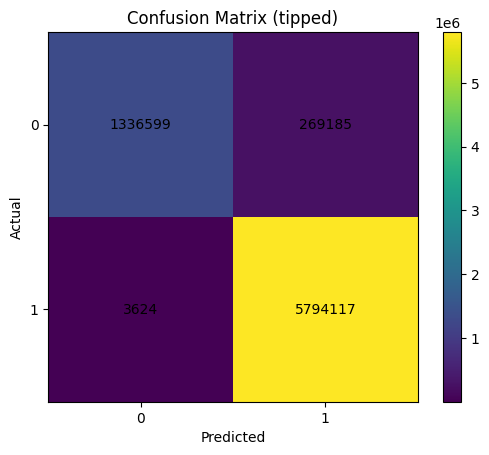

In [ ]:
plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix (tipped)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1])
plt.yticks([0,1])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.colorbar()
plt.show()


## 13) Logistic interpretation — odds ratios
Odds ratio = exp(beta), show top coefficients by magnitude so we’re not drowning in location dummies.


In [ ]:
def extract_logistic_odds_ratios(pipe: Pipeline, X: pd.DataFrame) -> pd.DataFrame:

    preprocess = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]

    num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]

    feature_names = []
    feature_names.extend(num_cols)

    if len(cat_cols) > 0:
        ohe = preprocess.named_transformers_["cat"].named_steps["onehot"]

        ohe_names = ohe.get_feature_names_out(cat_cols).tolist()
        feature_names.extend(ohe_names)

    coefs = model.coef_[0]
    out = pd.DataFrame({"feature": feature_names, "coef": coefs})
    out["odds_ratio"] = np.exp(out["coef"])
    out["abs_coef"] = out["coef"].abs()
    
    return out.sort_values("abs_coef", ascending=False).reset_index(drop=True)

odds_df = extract_logistic_odds_ratios(clf_model, X_clf)
odds_df.head(30)


,feature,coef,odds_ratio,abs_coef
0,payment_type,-3.068713,0.046481,3.068713
1,congestion_surcharge,0.730687,2.076507,0.730687
2,store_and_fwd_flag_N,0.690382,1.994478,0.690382
3,RatecodeID,-0.521550,0.593600,0.521550
4,store_and_fwd_flag_Y,0.481097,1.617849,0.481097
5,airport_fee,0.325152,1.384241,0.325152
6,trip_duration_min,-0.294727,0.744735,0.294727
7,trip_distance,0.169715,1.184967,0.169715
8,is_night,-0.137733,0.871332,0.137733
9,pickup_hour,0.106882,1.112803,0.106882


## 14) Permutation importance
If shuffling a feature column hurts performance, that feature mattered.
- Classification: AUC scoring
- Regression: R² scoring


In [ ]:
# classification permutation importance (AUC)

perm_clf = permutation_importance(
    clf_model, X_test_clf, y_test_clf,
    n_repeats=5, random_state=42, scoring="roc_auc"
)

imp_clf = pd.DataFrame({
    "feature": X_test_clf.columns,
    "importance_mean": perm_clf.importances_mean,
    "importance_std": perm_clf.importances_std
}).sort_values("importance_mean", ascending=False)

imp_clf.head(20)


,feature,importance_mean,importance_std
9,payment_type,0.375271,1.509911e-04
10,congestion_surcharge,0.008117,2.734816e-05
1,trip_duration_min,0.003885,5.328281e-05
13,RatecodeID,0.003656,1.086309e-05
6,is_night,0.002183,2.731519e-05
3,pickup_hour,0.001108,2.196130e-05
5,is_weekend,0.000679,1.060682e-05
7,PULocationID,0.000665,1.433195e-05
8,DOLocationID,0.000520,1.253643e-05
4,pickup_dow,0.000437,1.285312e-05


In [ ]:
# regression permutation importance R2

perm_reg = permutation_importance(
    reg_model, X_test_reg, y_test_reg,
    n_repeats=5, random_state=42, scoring="r2"
)

imp_reg = pd.DataFrame({
    "feature": X_test_reg.columns,
    "importance_mean": perm_reg.importances_mean,
    "importance_std": perm_reg.importances_std
}).sort_values("importance_mean", ascending=False)

imp_reg.head(20)


,feature,importance_mean,importance_std
1,trip_duration_min,4.435856e-01,4.996224e-05
0,trip_distance,3.547682e-01,1.282693e-04
9,payment_type,2.701712e-02,2.646830e-05
12,tolls_amount,1.106912e-02,2.197829e-05
11,airport_fee,6.099601e-03,1.475312e-05
13,RatecodeID,3.930236e-03,9.200878e-06
6,is_night,2.732501e-03,8.763190e-06
10,congestion_surcharge,2.108183e-03,8.908823e-06
3,pickup_hour,1.066478e-03,4.903335e-06
15,VendorID,8.213597e-04,1.277901e-06


## 15) Extra visuals

- Correlation heatmap
- Regression: predicted vs actual
- ROC curve for tipping model


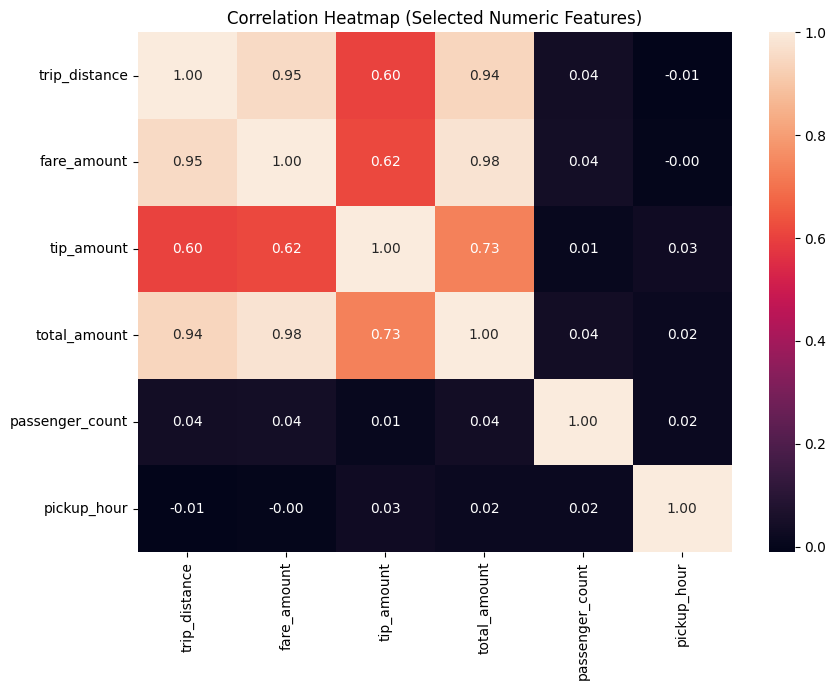

In [ ]:
# Correlation heatmap

import seaborn as sns

cols = ["trip_distance","fare_amount","tip_amount","total_amount","passenger_count","pickup_hour"]
cols = [c for c in cols if c in df.columns]

Xcorr = df[cols].copy()

corr = Xcorr.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f")
plt.title("Correlation Heatmap (Selected Numeric Features)")
plt.tight_layout()
plt.show()


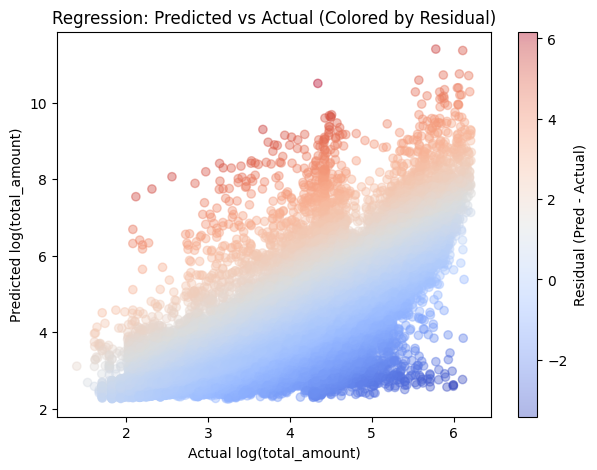

'Positive Residual (Red)\n\nPredicted > Actual\n\nThe model overpredicted the fare.\n\nExample:\n\nActual log(total) = 3.0\n\nPredicted log(total) = 4.0\n\nResidual = +1.0\n\nModel thinks the ride cost more than it really did.\n\nNegative Residual (Blue)\n\nPredicted < Actual\n\nThe model underpredicted the fare.\n\nActual = 5.0\n\nPredicted = 3.5\n\nResidual = -1.5\n\nModel thinks the ride cost less than it really did.\n\nNear Zero (White)\n\nPrediction ≈ Actual\n\nModel is accurate there.\n\n***Mid-range fares cluster near white → model performs well there.\n\nSome higher fares show red → model overpredicting.\n\nSome high fares show blue → model underpredicting.\n\nThis suggests:\n\nThe model performs best in the dense middle of the distribution and struggles with extreme values.***'

In [ ]:
residuals = pred_log_reg - y_test_reg

plt.figure(figsize=(7,5))
plt.scatter(y_test_reg, pred_log_reg,
            c=residuals, cmap="coolwarm", alpha=0.4)

plt.colorbar(label="Residual (Pred - Actual)")
plt.xlabel("Actual log(total_amount)")
plt.ylabel("Predicted log(total_amount)")
plt.title("Regression: Predicted vs Actual (Colored by Residual)")
plt.show()

'''Positive Residual (Red)

Predicted > Actual

The model overpredicted the fare.

Example:

Actual log(total) = 3.0

Predicted log(total) = 4.0

Residual = +1.0

Model thinks the ride cost more than it really did.

Negative Residual (Blue)

Predicted < Actual

The model underpredicted the fare.

Actual = 5.0

Predicted = 3.5

Residual = -1.5

Model thinks the ride cost less than it really did.

Near Zero (White)

Prediction ≈ Actual

Model is accurate there.

***Mid-range fares cluster near white → model performs well there.

Some higher fares show red → model overpredicting.

Some high fares show blue → model underpredicting.

This suggests:

The model performs best in the dense middle of the distribution and struggles with extreme values.***'''

AUC: 0.9159326168307428


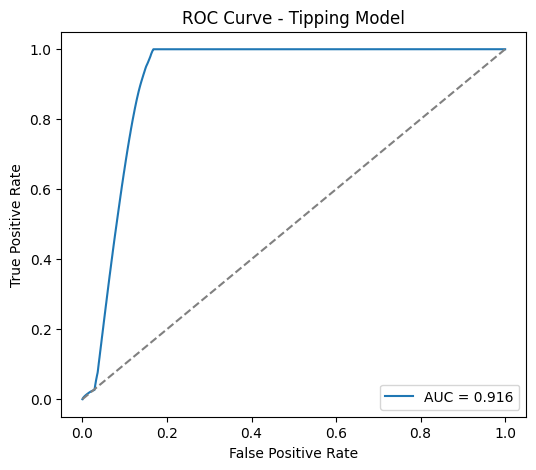

In [ ]:
# uses clf_model.predict_proba

fpr, tpr, _ = roc_curve(y_test_clf, proba_clf)

print("AUC:", roc_auc_score(y_test_clf, proba_clf))

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tipping Model")
plt.legend()
plt.show()


## 17) Additional visuals for the final presentation

These are **high-signal** visuals that are easy to explain:

- **Tip-rate heatmap (Day of Week × Hour)**: shows commute vs night-life behavior.
- **Borough summary**: trip volume, average total, and tip rate by pickup borough.
- **Trip behavior clustering (KMeans)**: segments trips into interpretable groups (short hops vs longer premium trips, etc.).
- **Regression residual plot**: checks where the regression is biased.


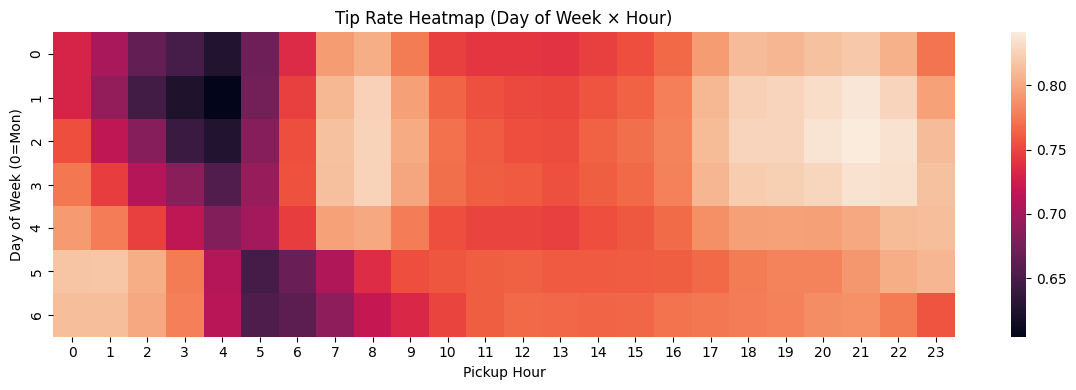

In [ ]:
# Tip-rate heatmap: Day of Week × Hour
import seaborn as sns

pivot_tip = df.pivot_table(
    values="tipped",
    index="pickup_dow",
    columns="pickup_hour",
    aggfunc="mean"
)

plt.figure(figsize=(12, 4))
sns.heatmap(pivot_tip, annot=False)
plt.title("Tip Rate Heatmap (Day of Week × Hour)")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week (0=Mon)")
plt.tight_layout()
plt.show()


,trips,mean_total,tip_rate
PU_borough,,,
Manhattan,32860608,24.023464,0.793682
Queens,3536318,73.437072,0.715030
Unknown,316062,30.827446,0.779603
Brooklyn,242081,33.699270,0.517174
Bronx,50950,34.522420,0.097547
Staten Island,1398,77.118255,0.100143
EWR,398,101.992915,0.597990


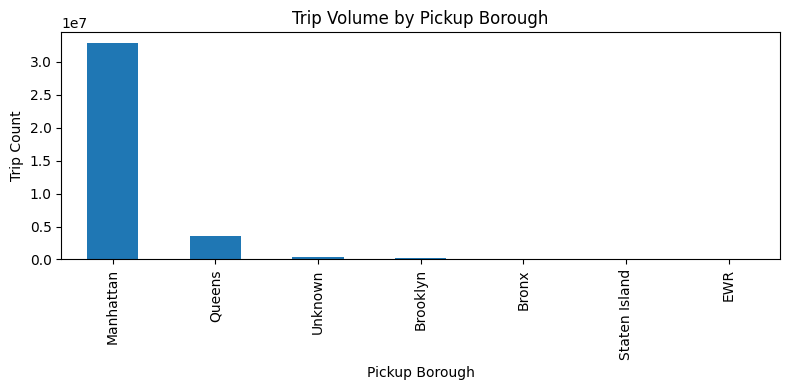

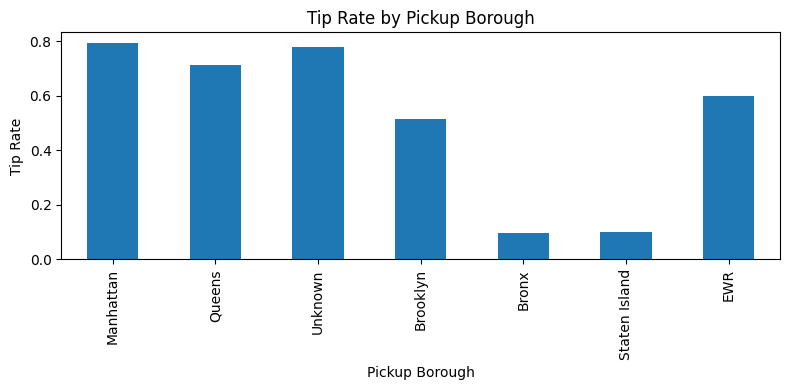

In [ ]:
# borough summary, zone mapping

if "PU_borough" in df.columns:
    borough_summary = df.groupby("PU_borough").agg(
        trips=("PU_borough","size"),
        mean_total=("total_amount","mean"),
        tip_rate=("tipped","mean")
    ).sort_values("trips", ascending=False)

    display(borough_summary)

    plt.figure(figsize=(8,4))

    borough_summary["trips"].plot(kind="bar")

    plt.title("Trip Volume by Pickup Borough")
    plt.xlabel("Pickup Borough")
    plt.ylabel("Trip Count")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8,4))

    borough_summary["tip_rate"].plot(kind="bar")

    plt.title("Tip Rate by Pickup Borough")
    plt.xlabel("Pickup Borough")
    plt.ylabel("Tip Rate")
    plt.tight_layout()
    plt.show()
    
else:
    print("PU_borough not found. Run the zone mapping cell first.")


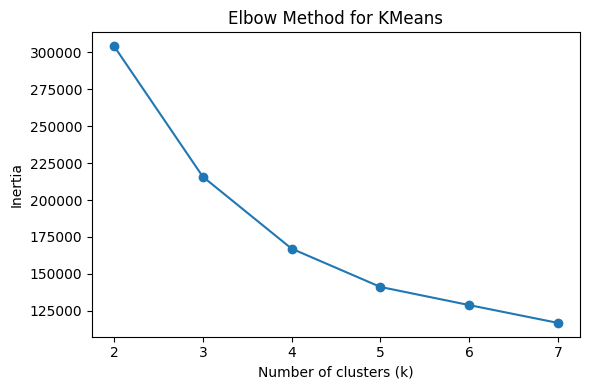

,trip_distance,trip_duration_min,total_amount,pickup_hour,tipped
cluster,,,,,
0,2.32,13.59,19.96,13.86,0.00
1,2.12,12.39,21.75,8.34,1.00
2,14.61,44.01,83.05,14.33,0.78
3,2.17,13.49,23.68,18.27,1.00


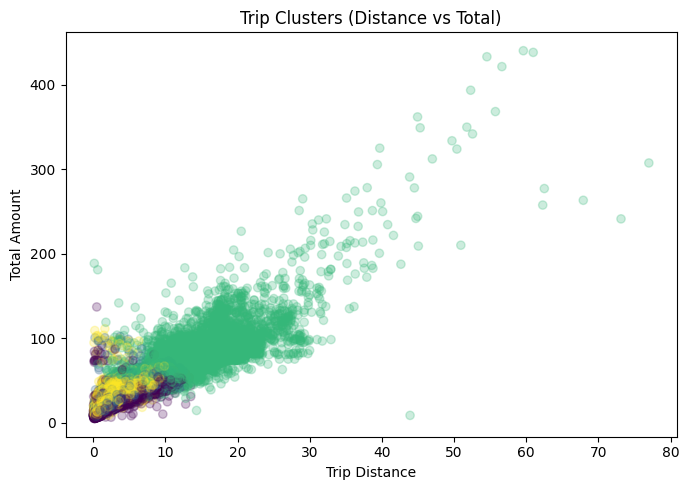

In [ ]:
# trip behavior KMeans

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cluster_features = ["trip_distance", "trip_duration_min", "total_amount", "pickup_hour", "tipped"]
cluster_df = df[cluster_features].dropna().copy()


CLUSTER_SAMPLE_N = 100_000

if len(cluster_df) > CLUSTER_SAMPLE_N:
    cluster_df = cluster_df.sample(CLUSTER_SAMPLE_N, random_state=42).reset_index(drop=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df)


inertia = []
K_RANGE = range(2, 8)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(list(K_RANGE), inertia, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for KMeans")
plt.tight_layout()
plt.show()


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df["cluster"] = kmeans.fit_predict(X_scaled)


# means profiles

cluster_profile = cluster_df.groupby("cluster").mean(numeric_only=True).round(2)
display(cluster_profile)


# distance vs total, colored by cluster

plt.figure(figsize=(7,5))
plt.scatter(cluster_df["trip_distance"], cluster_df["total_amount"], c=cluster_df["cluster"], alpha=0.25)
plt.xlabel("Trip Distance")
plt.ylabel("Total Amount")
plt.title("Trip Clusters (Distance vs Total)")
plt.tight_layout()
plt.show()


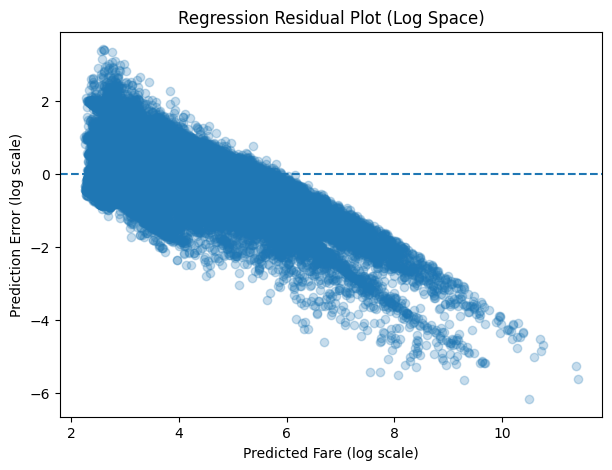

In [ ]:
log_residuals = y_test_reg - pred_log_reg

plt.figure(figsize=(7,5))
plt.scatter(pred_log_reg, log_residuals, alpha=0.25)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Fare (log scale)")
plt.ylabel("Prediction Error (log scale)")
plt.title("Regression Residual Plot (Log Space)")
plt.show()

In [ ]:
print("Max log prediction:", pred_log_reg.max())
print("Min log prediction:", pred_log_reg.min())
print("Max predicted dollars:", pred_dollars.max())
print("Max actual dollars:", y_test_dollars.max())

Max log prediction: 11.404989855631364
Min log prediction: 2.247457888353842
Max predicted dollars: 89767.53971257147
Max actual dollars: 499.9499999999999


## 16) What can be said to a stakeholder
- **Time-of-day:** quantify how totals shift (regression) and how odds of tipping shift (logistic).
- **Locations:** identify pickup/dropoff zones associated with higher totals or tipping likelihood.
- **Payment type:** show strong association with tipping.
- **Distance & duration:** remain dominant drivers of total cost.

## cleaning impact
- Speed-based filtering removed physically impossible trips that were leaking noise into both models.
- Fare floor enforcement removed refund/dispute rows that shouldn't be modeled as real trips.
- Deterministic imputation of surcharges (NaN -> 0) eliminated a source of subtle bias from median imputation on bimodal features.
- Deduplication removed vendor-resubmitted duplicate rows that would otherwise inflate certain trip patterns.

